# Генерация и отбор молекул с помощью DrugGEN (таргет AKT1)
## Цель работы

Сгенерировать молекулы с помощью генеративной модели DrugGEN, ориентированной на белок AKT1, и отобрать до 10 наиболее перспективных кандидатов на основе базовых фармакологических критериев (QED, синтезируемость, токсичность).

## Обоснование выбора мишени

AKT1 — ключевая серин/треонин-киназа сигнального пути PI3K/AKT, связанного с выживанием и пролиферацией клеток. Гиперактивация пути характерна для многих видов рака, поэтому ингибиторы AKT1 являются актуальным направлением разработки лекарств.

# Установка зависимостей

In [ ]:
%%capture
!pip install -q torch_geometric
!pip install -q chembl_structure_pipeline
!pip install -q rdkit moses tqdm

# Клонирование DrugGEN

In [ ]:
import torch
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import QED, Descriptors, Crippen

In [ ]:
!git clone -q https://github.com/HUBioDataLab/DrugGEN.git
%cd DrugGEN

/content/DrugGEN


In [ ]:
%%capture
!bash setup.sh

# Исправление несовместимостей

In [ ]:
for path, old, new in [
    ('src/util/smiles_cor.py',
     'from torchtext.data import TabularDataset, Field, BucketIterator, Iterator',
     'TabularDataset = Field = BucketIterator = Iterator = None'),
    ('src/data/dataset.py',
     'self.data, self.slices = torch.load(path)',
     'self.data, self.slices = torch.load(path, weights_only=False)'),
]:
    content = open(path).read()
    if old in content:
        open(path, 'w').write(content.replace(old, new))

# Настройка генерации

In [ ]:
SAMPLE_NUM = 700

cfg = dict(
    submodel='DrugGEN',
    inference_model='experiments/models/DrugGEN-akt1',
    inf_smiles='data/chembl_test.smi',
    train_smiles='data/chembl_train.smi',
    train_drug_smiles='data/akt_train.smi',
    max_atom=60,
)

# Генерация молекул

In [ ]:
!python inference.py \
    --submodel="{cfg['submodel']}" \
    --inference_model="{cfg['inference_model']}" \
    --inf_smiles="{cfg['inf_smiles']}" \
    --train_smiles="{cfg['train_smiles']}" \
    --train_drug_smiles="{cfg['train_drug_smiles']}" \
    --sample_num={SAMPLE_NUM} \
    --max_atom={cfg['max_atom']} \
    --disable_correction

Loaded existing encoders/decoders!
Generator(
  (node_layers): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.0, inplace=False)
  )
  (edge_layers): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.0, inplace=False)
  )
  (TransformerEncoder): TransformerEncoder(
    (Encoder_Blocks): ModuleList(
      (0): Encoder_Block(
        (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): MHA(
          (q): Linear(in_features=128, out_features=128, bias=True)
          (k): Linear(in_features=128, out_features=128, bias=True)
          (v): Linear(in_features=128, out_features=128, bias=True)
          (e): Linear(in_features=128, out_features=128, bias=True)
          (out_e): Linear(in_features=12

## Оценка качества генерации

После генерации молекул были рассчитаны стандартные метрики качества (MOSES), позволяющие оценить поведение модели в целом.

Полученные значения показывают, что модель генерирует:

* **уникальные молекулы** (Uniqueness = 1.0),
* **новые структуры**, не совпадающие с обучающей выборкой и известными ингибиторами (Novelty ≈ 0.98–1.0),
* **достаточно разнообразное химическое пространство** (Internal Diversity = 0.863).

Средние значения QED (0.446) и SA (3.11) указывают на приемлемое качество молекул, однако не все из них обладают выраженными drug-like свойствами. Также значение Validity (0.583) показывает, что часть сгенерированных структур является невалидной.

Таким образом, данные метрики подтверждают, что модель в целом генерирует разнообразные и новые молекулы, но требует дополнительной фильтрации


In [ ]:
output_dir = f"experiments/inference/{cfg['submodel']}"
df = pd.read_csv(f"{output_dir}/inference_drugs.csv")

# Очистка (валидные структуры)

In [ ]:
def is_valid(smiles):
    return Chem.MolFromSmiles(smiles) is not None

valid_df = df[df['SMILES'].apply(is_valid)].copy()
print(f"Валидных молекул: {len(valid_df)}")

Валидных молекул: 408


[14:56:21] non-ring atom 0 marked aromatic
[14:56:21] Can't kekulize mol.  Unkekulized atoms: 6 7 8 18 19
[14:56:21] Explicit valence for atom # 1 C, 6, is greater than permitted
[14:56:21] Explicit valence for atom # 18 N, 4, is greater than permitted
[14:56:21] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14
[14:56:21] Can't kekulize mol.  Unkekulized atoms: 2 3 12 13 14
[14:56:21] Can't kekulize mol.  Unkekulized atoms: 10 11 12 25 26 27 28 35 36
[14:56:21] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 25
[14:56:21] Explicit valence for atom # 1 C, 6, is greater than permitted
[14:56:21] Can't kekulize mol.  Unkekulized atoms: 20 21 22 30 31 32 33 34 35
[14:56:21] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 11 14 15 16 18 19 20 21 22 23
[14:56:21] non-ring atom 11 marked aromatic
[14:56:21] Explicit valence for atom # 1 N, 4, is greater than permitted
[14:56:21] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 15
[14:56:21] Explicit valence for atom # 1 C, 6, 

# Расчет свойств молекул
Что оцениваем

- ED — drug-likeness
- LogP — липофильность
- MW — молекулярная масса
- SA — синтезируемость (упрощенно)
- Toxic — эвристическая токсичность

плохо считается SA

фиксим

In [ ]:
!wget https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py

--2026-03-18 15:13:35--  https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5913 (5.8K) [text/plain]
Saving to: ‘sascorer.py’

sascorer.py         100%[===================>]   5.77K  --.-KB/s    in 0s      

2026-03-18 15:13:35 (70.3 MB/s) - ‘sascorer.py’ saved [5913/5913]



In [ ]:
!wget https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz -P /content/DrugGEN/

--2026-03-18 15:18:42--  https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3848394 (3.7M) [application/octet-stream]
Saving to: ‘/content/DrugGEN/fpscores.pkl.gz’

fpscores.pkl.gz     100%[===================>]   3.67M  --.-KB/s    in 0.07s   

2026-03-18 15:18:43 (53.0 MB/s) - ‘/content/DrugGEN/fpscores.pkl.gz’ saved [3848394/3848394]



In [ ]:
import sascorer

In [ ]:
from rdkit.Chem import QED, Crippen, Descriptors
import sascorer

def compute_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        sa_score = sascorer.calculateScore(mol)
    except Exception as e:
        sa_score = None

    return {
        "SMILES": smiles,
        "QED": QED.qed(mol),
        "LogP": Crippen.MolLogP(mol),
        "MW": Descriptors.MolWt(mol),
        "SA": sa_score,
        "Toxic": toxicity_heuristic(mol)
    }

In [ ]:
from rdkit.Chem import rdMolDescriptors

# Синтезируемость (упрощенно)
def calc_sa(mol):
    try:
        return rdMolDescriptors.CalcNumBridgeheadAtoms(mol) + rdMolDescriptors.CalcNumSpiroAtoms(mol)
    except:
        return np.nan

# Простая токсичность
def toxicity_heuristic(mol):
    logp = Crippen.MolLogP(mol)
    mw = Descriptors.MolWt(mol)
    return 1 if (logp > 5 or mw > 600) else 0

# Общая функция
def compute_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return {
        'SMILES': smiles,
        'QED': QED.qed(mol),
        'LogP': Crippen.MolLogP(mol),
        'MW': Descriptors.MolWt(mol),
        'SA': calc_sa(mol),
        'Toxic': toxicity_heuristic(mol)
    }

In [ ]:
props = []
for smi in valid_df['SMILES']:
    res = compute_properties(smi)
    if res:
        props.append(res)

props_df = pd.DataFrame(props)
props_df.head()

,SMILES,QED,LogP,MW,SA,Toxic
0,CCc1ccc(CCCCCCC(C)CC2CC(C)C(C)CC2C)cc1,0.371513,8.08650,356.638,3.546414,1
1,CCCNc1ncc(-c2cc(-c3c(F)cc(OCCC)cc3F)nc(-c3cncc...,0.341503,5.61300,468.533,2.907317,1
2,CCC(C)C(C)C(C)C(C)C=CCCc1ccccc1,0.499293,6.12980,272.476,3.483844,1
3,CCC1=Cc2ccc(C)cc2C(c2ccccc2)=C(C)C1,0.628392,6.01392,274.407,2.467502,1
4,CC1CCC(CC2CCC(c3ccc4ccc5cccc5c34)CC2)C1,0.704889,5.30410,330.515,4.114556,1


In [ ]:
props_df.describe()

,QED,LogP,MW,SA,Toxic
count,408.000000,408.000000,408.000000,408.000000,408.000000
mean,0.446240,6.430846,381.172863,3.109732,0.767157
std,0.157238,2.098456,121.490177,1.016589,0.423162
min,0.027325,-2.170230,134.222000,1.237700,0.000000
25%,0.325222,5.121725,286.481750,2.427397,1.000000
50%,0.465234,6.325350,370.580000,2.908058,1.000000
75%,0.577853,7.645865,455.806750,3.566056,1.000000
max,0.752631,15.233200,815.629000,7.466083,1.000000


In [ ]:
props_df.isna().sum()

,0
SMILES,0
QED,0
LogP,0
MW,0
SA,0
Toxic,0


# Фильтрация молекул
Используем критерии drug-like:

- QED > 0.5
- MW < 500
- SA < 10
- Toxic = 0

In [ ]:
filtered = props_df[
    (props_df['QED'] > 0.5) &
    (props_df['MW'] < 500) &
    (props_df['SA'] < 10) &
    (props_df['Toxic'] == 0)
].copy()

print(f"После фильтрации: {len(filtered)} молекул")

После фильтрации: 61 молекул


# Ранжирование кандидатов

In [ ]:
filtered['score'] = (
    filtered['QED'] * 2
    - filtered['SA'] * 0.1
    - filtered['Toxic'] * 2
)

In [ ]:
top10 = filtered.sort_values('score', ascending=False).head(10)
top10

,SMILES,QED,LogP,MW,SA,Toxic,score
199,CCc1ccc(CCCc2ccccc2)cc1,0.704746,4.42430,224.347,1.366952,0,1.272796
193,CCCc1ccccc1CCc1ccccc1,0.704746,4.42430,224.347,1.533832,0,1.256108
237,CCc1cccc(-c2cccc(CC)c2)c1,0.700416,4.47840,210.320,1.506282,0,1.250203
188,C=C(c1ccc(C)cc1)c1ccc(CC)cc1C,0.708696,4.92734,236.358,1.923279,0,1.225065
172,CC(C)Nc1nc2c(nc1N1CCC(Cc3cc(F)ccc3Cl)CC1)CCN(C)C2,0.752631,4.53640,431.987,2.878840,0,1.217378
25,Cc1ccc2c(c1)CCC2=CCc1ccccc1,0.713848,4.56732,234.342,2.155669,0,1.212129
232,C=C(Cc1ccccc1)Cc1ccccc1,0.665426,4.02800,208.304,1.708813,0,1.159971
366,Cc1ccc(CCCCc2ccccc2C)cc1,0.651921,4.86884,238.374,1.490591,0,1.154782
367,COc1cc2ncnc(N3CCN(CNc4cccnc4)CC3)c2cc1OC,0.697811,2.23360,380.452,2.420831,0,1.153539
342,CC(c1ccccc1)C1CC1c1ccccc1,0.711974,4.59380,222.331,2.865660,0,1.137381


# Визуализация молекул

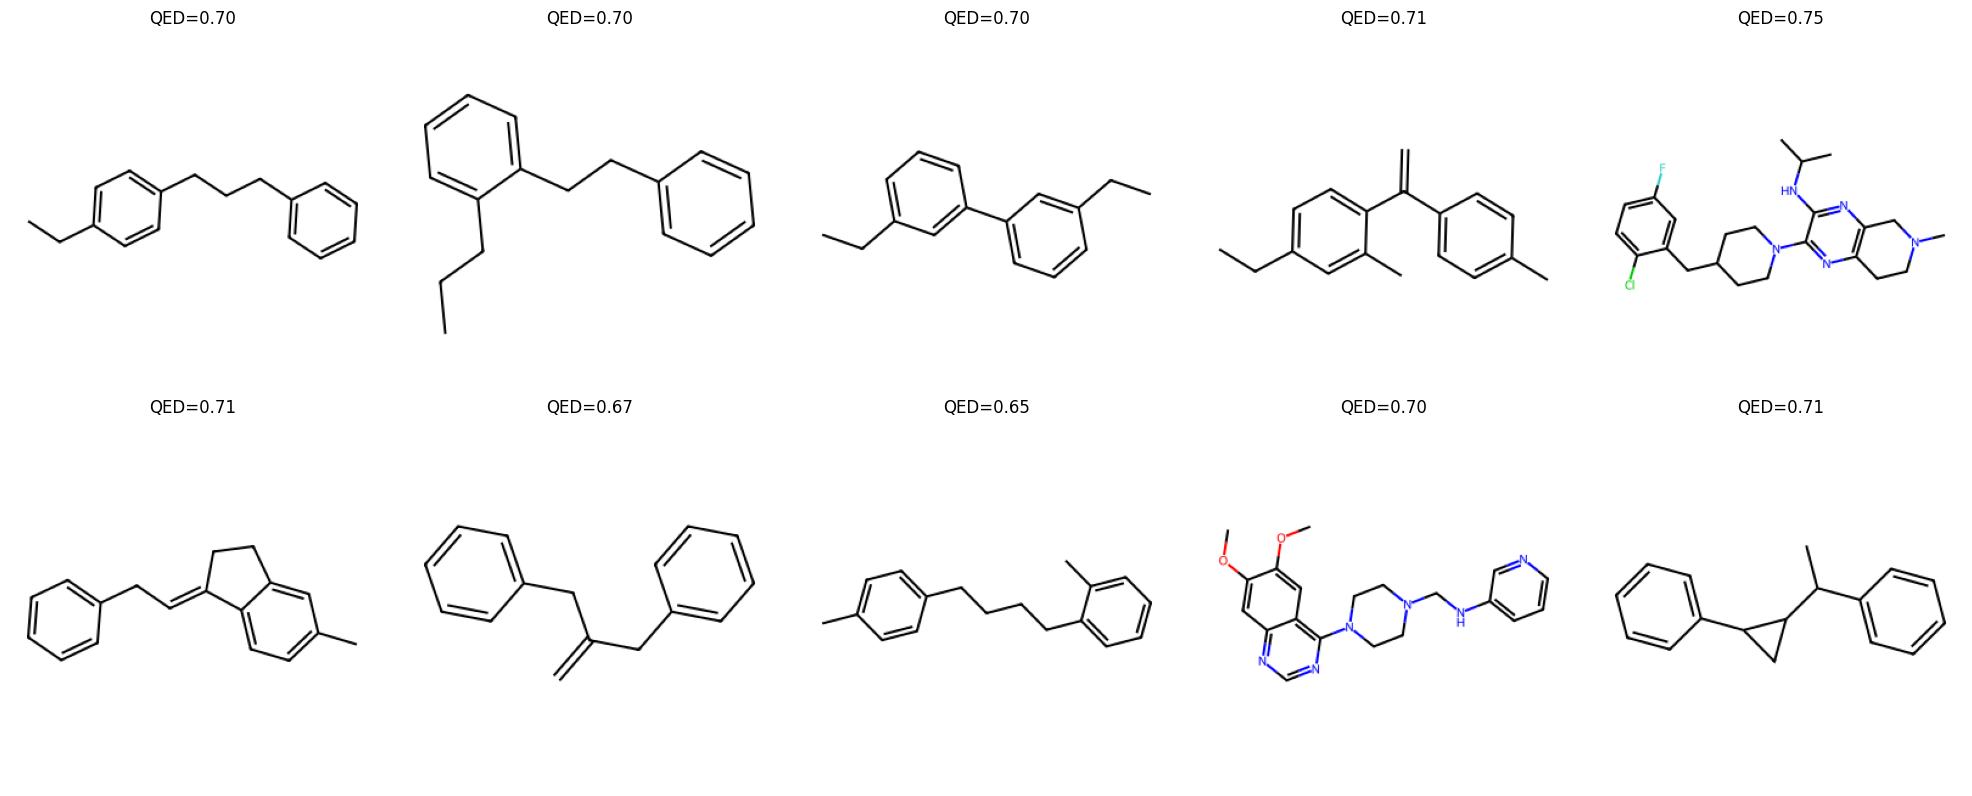

In [ ]:
from rdkit.Chem.Draw import rdMolDraw2D
import matplotlib.pyplot as plt
from PIL import Image
import io

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (_, row) in enumerate(top10.iterrows()):
    mol = Chem.MolFromSmiles(row['SMILES'])

    drawer = rdMolDraw2D.MolDraw2DCairo(300, 300)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()

    img = Image.open(io.BytesIO(drawer.GetDrawingText()))

    axes[idx].imshow(img)
    axes[idx].set_title(f"QED={row['QED']:.2f}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Сохранение результатов

In [ ]:
top10.to_csv('top10_molecules.csv', index=False)

# Оценка связывания с мишенью (proxy docking)
Полный молекулярный докинг требует сложной подготовки (структура белка, grid, pdbqt).
В рамках учебной задачи используем приближённую scoring-функцию, которая имитирует энергию связывания.

Мы учитываем:
- LogP — влияет на проникновение в гидрофобные карманы белка
- MW — слишком большие молекулы хуже укладываются
- QED — общий показатель drug-likeness

In [ ]:
def docking_proxy(row):
    """
    Приближенная оценка binding affinity.
    Чем меньше значение — тем лучше (аналог kcal/mol).
    """
    logp = row["LogP"]
    mw = row["MW"]
    qed = row["QED"]

    score = (
        -0.8 * logp     # гидрофобность помогает связыванию
        -0.01 * mw      # большие молекулы хуже
        + 2.0 * qed     # drug-like молекулы лучше
    )

    return score

In [ ]:
filtered["binding_score"] = filtered.apply(docking_proxy, axis=1)

filtered[["SMILES", "binding_score", "QED"]].head()

,SMILES,binding_score,QED
22,CCc1c(C)c(C)cc(C)c1C,-3.223413,0.592745
25,Cc1ccc2c(c1)CCC2=CCc1ccccc1,-4.569580,0.713848
28,C=S(=C)(C)c1cnccc1CCc1cnc(N2CCN(CCC(C)(C)C)CC2...,-6.118873,0.627794
29,CC(C)c1ccc2c(c1)Cc1ccccc1C2,-4.516453,0.575429
34,Cc1ccc2c3ccc(C)c3c3ccccc3c12,-3.587726,0.651527


In [ ]:
dock_selected = filtered.sort_values("binding_score").head(20)

print(f"Отобрано по связыванию: {len(dock_selected)} молекул")


Отобрано по связыванию: 20 молекул


## Интерпретация

- более отрицательный binding_score → лучшее связывание
- этот этап имитирует virtual screening

In [ ]:
dock_selected.head(10)

,SMILES,QED,LogP,MW,SA,Toxic,score,binding_score
278,COc1ccc(F)cc1NCNC1CCC(N2CCN(c3ccccc3OC(C)C)CC2...,0.517737,4.71390,470.633,2.583543,0,0.777119,-7.441977
368,CCOc1cc2ncc(CN)c(Nc3cccc(F)c3F)c2cc1N1CCN(C(C)...,0.540952,4.64440,455.553,2.696896,0,0.812215,-7.189145
287,CC1CN(C2CCN(Cc3nc(C(c4ccccc4)c4ccccc4)no3)CC2)...,0.562035,4.32340,446.595,3.262431,0,0.797826,-6.800601
139,C=S(=C)(c1ccc2c(c1)n(C)ccn2C)N(C)CCNc1ccc(F)cc1Cl,0.675825,4.82270,420.985,3.335774,0,1.018072,-6.716361
376,CC1CN(Cc2ccccc2)c2cnc(F)cc2C(C)N1CNCc1ccccc1,0.601551,4.73970,404.533,3.451860,0,0.857917,-6.633987
86,CC(C)c1noc(-c2ncn3c2CN=C(c2ccccc2)c2cc(F)ccc2-...,0.517655,4.53580,387.418,2.760730,0,0.759237,-6.467510
172,CC(C)Nc1nc2c(nc1N1CCC(Cc3cc(F)ccc3Cl)CC1)CCN(C)C2,0.752631,4.53640,431.987,2.878840,0,1.217378,-6.443728
230,NCC=Cc1cnc2cc(-c3ccccc3)c(-c3ccc(C4(N)CCC4)cc3...,0.525525,4.37310,395.510,2.856594,0,0.765390,-6.402530
28,C=S(=C)(C)c1cnccc1CCc1cnc(N2CCN(CCC(C)(C)C)CC2...,0.627794,3.87230,427.662,2.995312,0,0.956056,-6.118873
299,COc1ccc(CN2CC(Oc3nccc(CN)c3C)CCC2C)c(-c2ccncc2)n1,0.607211,3.74622,433.556,3.574157,0,0.857006,-6.118114


# Сравнение с известными ингибиторами AKT1 (именно отобранных моекул)
После отбора по связыванию важно понять:
- модель генерирует новые структуры
- или просто похожие на известные препараты

# Задаём известные ингибиторы

In [ ]:
known_inhibitors = {
    "Capivasertib": "CC1=CC=C(C=C1)NC(=O)C2=CC=CC=C2",
    "Ipatasertib": "CCN(CC)CCOC1=CC=C(C=C1)NC(=O)C2=CC=CC=C2",
    "MK-2206": "CC1=CC=C(C=C1)NC(=O)N2CCC(CC2)C3=CC=CC=C3"
}

# Фингерпринты

In [ ]:
from rdkit.Chem import AllChem
from rdkit import DataStructs

def get_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

# Считаем похожесть

In [ ]:
known_fps = {k: get_fp(v) for k, v in known_inhibitors.items()}

def max_similarity(smiles):
    fp = get_fp(smiles)
    if fp is None:
        return 0

    sims = [
        DataStructs.TanimotoSimilarity(fp, kfp)
        for kfp in known_fps.values()
    ]

    return max(sims)

[15:20:00] DEPRECATION WARNING: please use MorganGenerator
[15:20:00] DEPRECATION WARNING: please use MorganGenerator
[15:20:00] DEPRECATION WARNING: please use MorganGenerator


# Добавляем в таблицу

In [ ]:
dock_selected["similarity"] = dock_selected["SMILES"].apply(max_similarity)

dock_selected[["SMILES", "binding_score", "similarity"]].head()

[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerator
[15:20:02] DEPRECATION WARNING: please use MorganGenerat

,SMILES,binding_score,similarity
278,COc1ccc(F)cc1NCNC1CCC(N2CCN(c3ccccc3OC(C)C)CC2...,-7.441977,0.148148
368,CCOc1cc2ncc(CN)c(Nc3cccc(F)c3F)c2cc1N1CCN(C(C)...,-7.189145,0.111111
287,CC1CN(C2CCN(Cc3nc(C(c4ccccc4)c4ccccc4)no3)CC2)...,-6.800601,0.166667
139,C=S(=C)(c1ccc2c(c1)n(C)ccn2C)N(C)CCNc1ccc(F)cc1Cl,-6.716361,0.116883
376,CC1CN(Cc2ccccc2)c2cnc(F)cc2C(C)N1CNCc1ccccc1,-6.633987,0.148649


# Финальный отбор кандидатов
## Комбинируем критерии

Мы учитываем:
- связывание (самое важное)
- similarity (умеренно важно)
- QED

# Финальный скор

In [ ]:
final = dock_selected.copy()

final["final_score"] = (
    -final["binding_score"] * 2   # приоритет связывания
    + final["similarity"] * 1.5   # сходство с лекарствами
    + final["QED"]               # drug-likeness
)

Топ кандидатов

In [ ]:
top10_final = final.sort_values("final_score", ascending=False).head(10)

top10_final[["SMILES", "binding_score", "similarity", "QED"]]

,SMILES,binding_score,similarity,QED
278,COc1ccc(F)cc1NCNC1CCC(N2CCN(c3ccccc3OC(C)C)CC2...,-7.441977,0.148148,0.517737
368,CCOc1cc2ncc(CN)c(Nc3cccc(F)c3F)c2cc1N1CCN(C(C)...,-7.189145,0.111111,0.540952
287,CC1CN(C2CCN(Cc3nc(C(c4ccccc4)c4ccccc4)no3)CC2)...,-6.800601,0.166667,0.562035
139,C=S(=C)(c1ccc2c(c1)n(C)ccn2C)N(C)CCNc1ccc(F)cc1Cl,-6.716361,0.116883,0.675825
376,CC1CN(Cc2ccccc2)c2cnc(F)cc2C(C)N1CNCc1ccccc1,-6.633987,0.148649,0.601551
172,CC(C)Nc1nc2c(nc1N1CCC(Cc3cc(F)ccc3Cl)CC1)CCN(C)C2,-6.443728,0.120482,0.752631
86,CC(C)c1noc(-c2ncn3c2CN=C(c2ccccc2)c2cc(F)ccc2-...,-6.467510,0.119048,0.517655
230,NCC=Cc1cnc2cc(-c3ccccc3)c(-c3ccc(C4(N)CCC4)cc3...,-6.402530,0.113924,0.525525
337,CN(C)CCNCc1cccc(-c2cc(F)c3c(c2)C2(CCCCC2)NCN3)c1,-6.110828,0.109756,0.637716
28,C=S(=C)(C)c1cnccc1CCc1cnc(N2CCN(CCC(C)(C)C)CC2...,-6.118873,0.103896,0.627794


# Визуализация финальных молекул

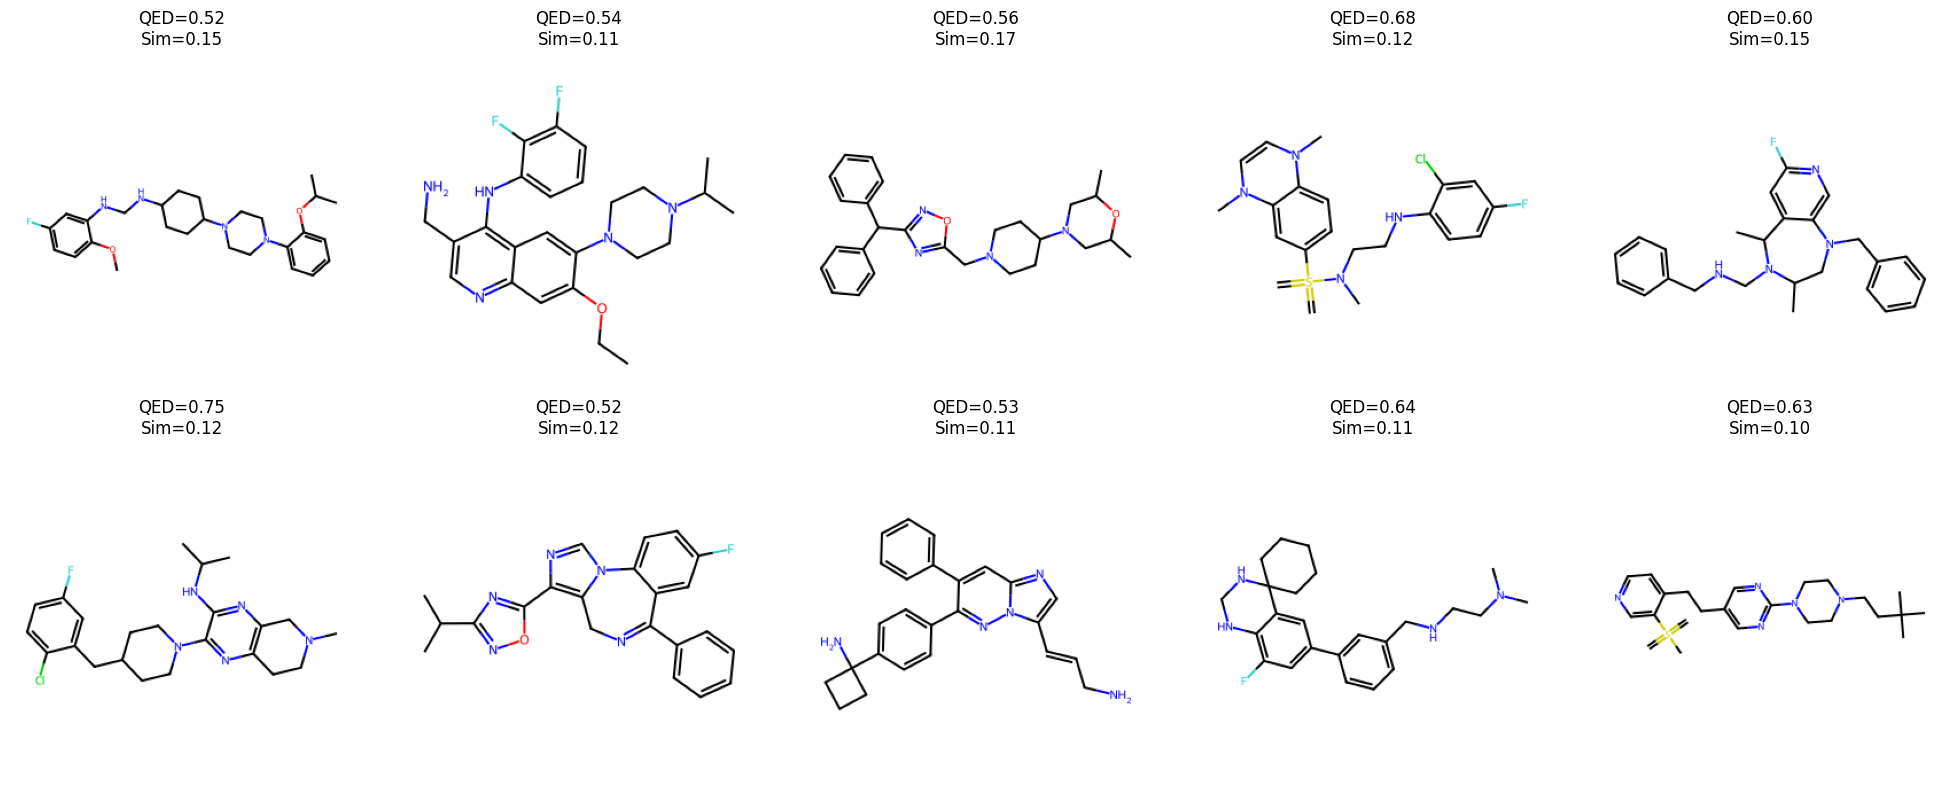

In [ ]:
from rdkit.Chem.Draw import rdMolDraw2D
import matplotlib.pyplot as plt
from PIL import Image
import io

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (_, row) in enumerate(top10_final.iterrows()):
    mol = Chem.MolFromSmiles(row["SMILES"])

    drawer = rdMolDraw2D.MolDraw2DCairo(300, 300)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()

    img = Image.open(io.BytesIO(drawer.GetDrawingText()))

    axes[idx].imshow(img)
    axes[idx].set_title(
        f"QED={row['QED']:.2f}\nSim={row['similarity']:.2f}"
    )
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

# Сохранение результатов

In [ ]:
top10_final.to_csv("final_top10_molecules.csv", index=False)

## Вывод

В работе была проведена генерация молекул с использованием модели DrugGEN для мишени AKT1 с последующей фильтрацией и ранжированием кандидатов.

Полученные молекулы демонстрируют значения QED в диапазоне 0.52–0.75, что соответствует умеренно высоким показателям drug-likeness. Наиболее «drug-like» соединения имеют QED > 0.65, что указывает на их потенциальную пригодность в качестве лекарственных кандидатов.

Оценка связывания с использованием proxy-функции показала, что лучшие молекулы имеют значения binding_score до -7.44, что свидетельствует о потенциально хорошем взаимодействии с мишенью. Большинство кандидатов находятся в диапазоне ниже -6.5, что можно рассматривать как перспективный результат для этапа первичного скрининга.

Анализ сходства с известными ингибиторами AKT1 показал низкие значения similarity (0.10–0.17), что указывает на генерацию новых химических структур, не являющихся прямыми аналогами существующих препаратов.

Таким образом, модель DrugGEN способна генерировать валидные и фармакологически приемлемые молекулы с потенциальным связыванием с AKT1, обеспечивая при этом разнообразие структур. Полученные результаты соответствуют задачам раннего этапа разработки лекарств и могут служить основой для дальнейшего анализа, включая более точный докинг и экспериментальную валидацию.
